<a href="https://colab.research.google.com/github/ezNobson/ML-AGH/blob/main/BostonHousing_Supervised_ML_AGH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Supervised Machine Learning - Prediction**
---
Autor: Michał Dyrek
---
Data: 2025-12-11
---
Data Science
---

## **Dataset**
This notebook provides regression task for "Boston Housing" dataset.

- Input variables:
  - **CRIM** - Per capita crime rate by town.
  - **ZN** - Proportion of residential land zoned for lots over 25,000 sq.ft.
  - **INDUS** - Proportion of non-retail business acres per town.
  - **CHAS** - Charles River dummy variable: 1 if tract borders river, 0 otherwise.
  - **NOX** - Nitric oxides concentration (parts per 10 million).
  - **RM** - Average number of rooms per dwelling.
  - **AGE** - Proportion of owner-occupied units built prior to 1940.
  - **DIS** - Weighted mean of distances to five Boston employment centers.
  - **RAD** - Index of accessibility to radial highways.
  - **TAX** - Full-value property-tax rate per $10,000.
  
  - **PTRATIO** - Pupil-teacher ratio by town.
  - **B** - A calculated variable based on the proportion of Black residents by town.
  - **LSTAT** - Percentage of lower status population.
- Target Variable
   - **MEDV** - Median value of owner-occupied homes in $1000s.















## **1) Loading and extracting basic statistics**

In [ ]:
import requests
import zipfile

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data"
response = requests.get(url)
filename = "housing_data.csv"

if response.status_code == 200:
    with open(filename, 'wb') as f:
        f.write(response.content)

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
names = ['CRIM', 'ZN', 'INUDS','CHAS','NOX', 'RM', 'AGE', 'DIS','RAD', 'TAX', 'PTRATIO','B','LSTAT','MEDV']

In [ ]:
raw_df = pd.read_csv("/content/housing_data.csv",names= names, delim_whitespace = True)
raw_df.head()

/tmp/ipython-input-1372356724.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  raw_df = pd.read_csv("/content/housing_data.csv",names= names, delim_whitespace = True)


,CRIM,ZN,INUDS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INUDS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


There are no `NA` values and all the variables are numerical values.

In [ ]:
df= raw_df.copy()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

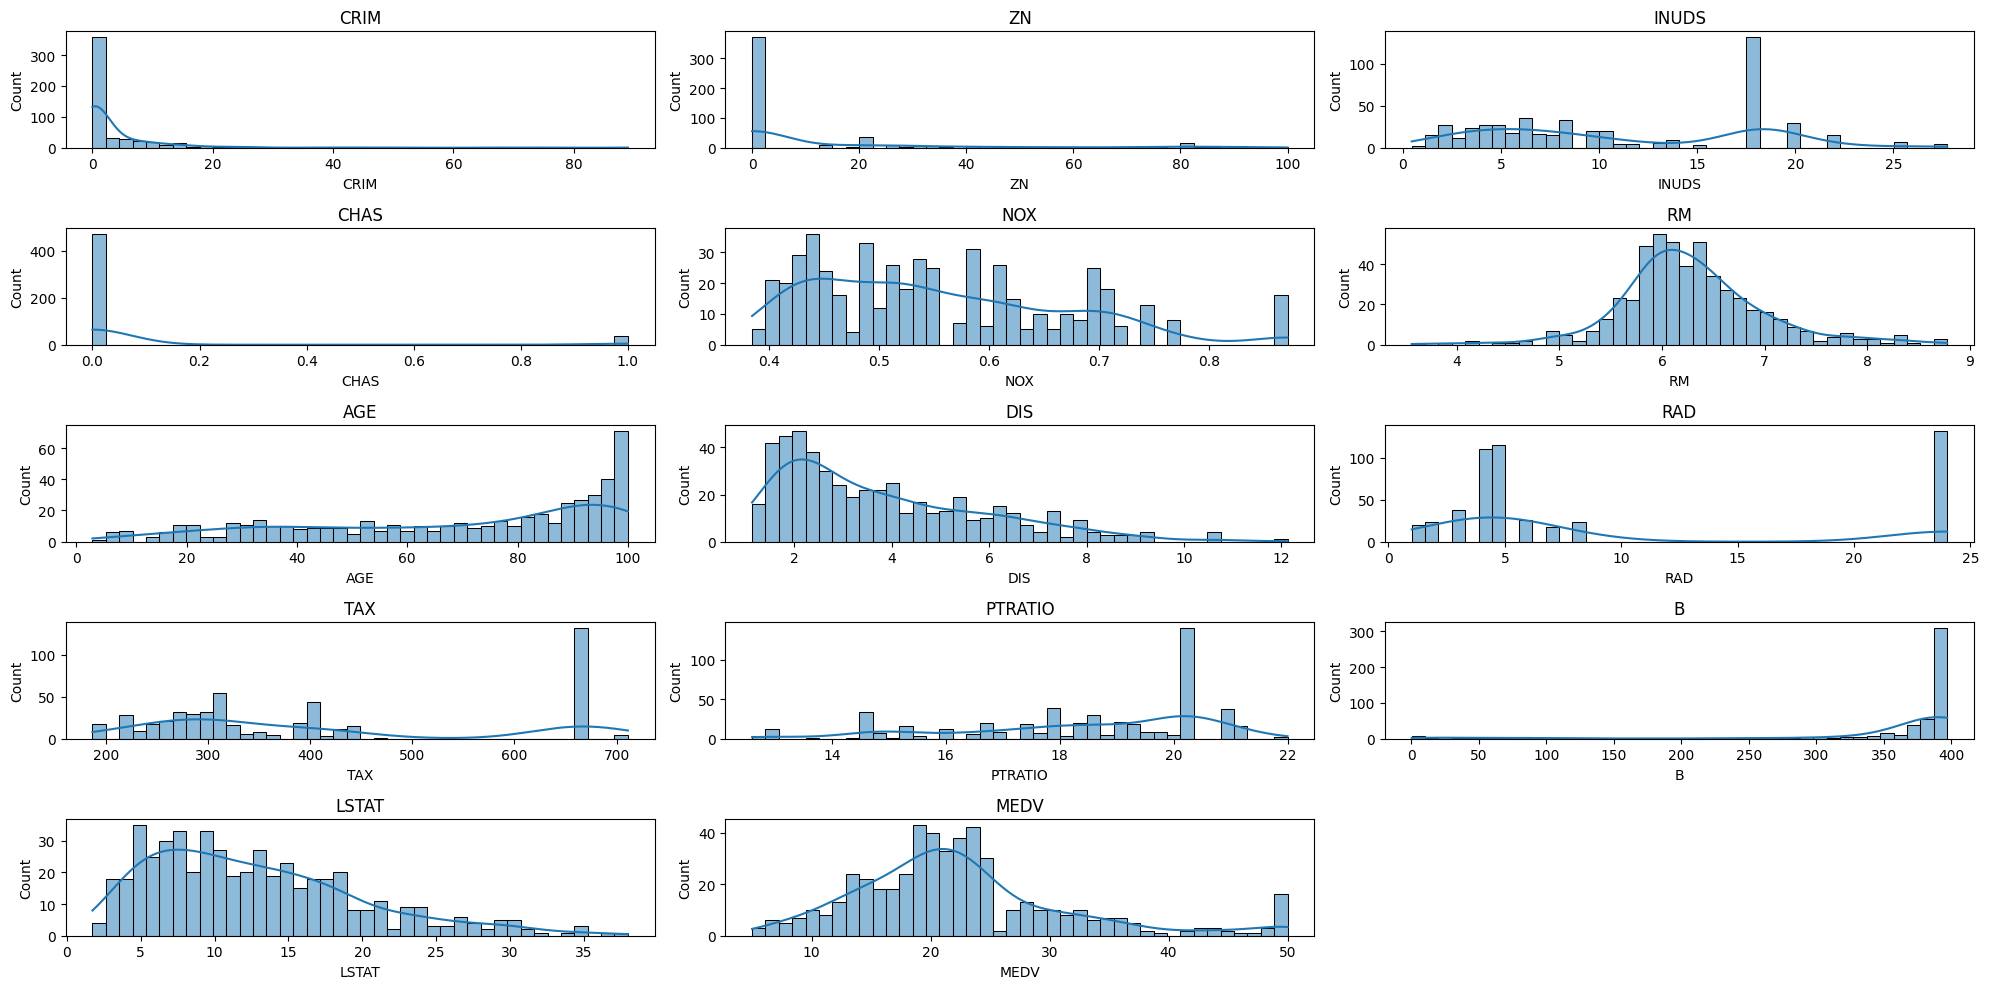

In [ ]:
plt.figure(figsize=(20, 10))
rows = int(np.ceil(len(names)/3))
for i,c in enumerate(df.columns,1):
    plt.subplot(rows, 3, i)
    sns.histplot(df[c].dropna(), kde=True, bins=40)
    plt.title(c)
plt.tight_layout()
plt.show()

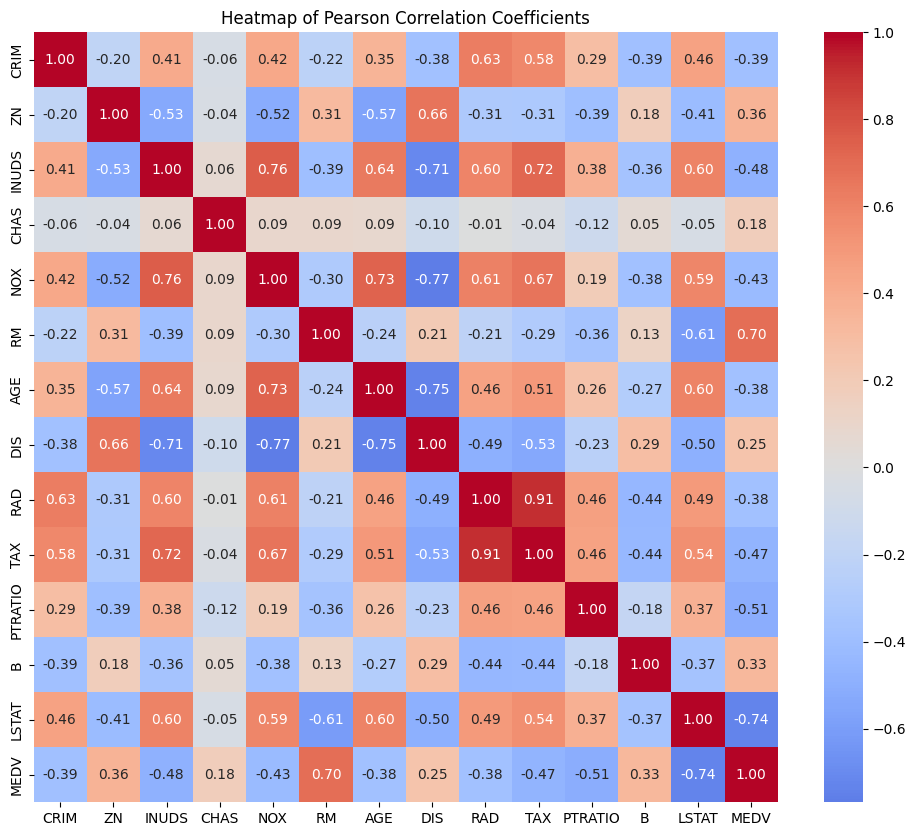

In [ ]:
corr_matrix = df.corr(method="pearson")
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot = True, fmt=".2f")
plt.title("Heatmap of Pearson Correlation Coefficients")
plt.show()

## **2) Split and Linear Regression Model**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [ ]:
print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (506, 13)
Shape of y:  (506,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
lr_model = LinearRegression()

In [ ]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr_model.predict(X_test)

In [ ]:
print("Linear Regression - MSE: ", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression - R2: ", r2_score(y_test, y_pred_lr))
print("Linear Regression - MAE: ", mean_absolute_error(y_test, y_pred_lr))

Linear Regression - MSE:  24.291119474973478
Linear Regression - R2:  0.6687594935356326
Linear Regression - MAE:  3.189091965887837


Results are mid but because we didn't preprocess our data at all. It'll be better if we sacle our data or use other transforms because Linear Regression learns from distance values so it's important to preserve the same scale for every feature.

## **3) XGBoost with GridSearch**

In [ ]:
import xgboost as xgb

In [ ]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', colsample_bytree = 0.3, learning_rate =0.1,
                             max_depth = 5, alpha = 10, n_estimators = 10)

In [ ]:
xgb_model.fit(X_train, y_train)

XGBRegressor(alpha=10, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10,
             n_jobs=None, ...)

In [ ]:
y_pred_xgb_base = xgb_model.predict(X_test)

In [ ]:
print("XGBoost Regressor - MSE: ", mean_squared_error(y_test, y_pred_xgb_base))
print("XGBoost Regressor - R2: ", r2_score(y_test, y_pred_xgb_base))
print("XGBoost Regressor - MAE: ", mean_absolute_error(y_test, y_pred_xgb_base))

XGBoost Regressor - MSE:  40.061291602494165
XGBoost Regressor - R2:  0.4537130108927857
XGBoost Regressor - MAE:  4.234852414972642


We see that results are really bad but this is because XGBoost is highly affected by hyperparameters so we should try to find most optimal ones.

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
params ={'learning_rate': [0.01, 0.06 ,0.1, 0.3],
         'max_depth': [3,5,7],
         'n_estimators': [50, 100, 200, 300]}

In [ ]:
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', colsample_bytree = 0.3)

In [ ]:
grid_xgb = GridSearchCV(estimator = xgb_base,param_grid=  params, cv=5,scoring ='neg_mean_squared_error', verbose=1)

In [ ]:
grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.3,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.06, 0.1, 0.3],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
xgb_best_model = grid_xgb.best_estimator_
xgb_best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.06, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print("Best parameters: ", grid_xgb.best_params_)
print("Best score: ", grid_xgb.score(X_test, y_test))

Best parameters:  {'learning_rate': 0.06, 'max_depth': 3, 'n_estimators': 300}
Best score:  -7.995016213924228


In [ ]:
y_pred_xgb_best = xgb_best_model.predict(X_test)

In [ ]:
print("XGBoost Regressor (TUNED) - MSE: ", mean_squared_error(y_test, y_pred_xgb_best))
print("XGBoost Regressor (TUNED) - R2: ", r2_score(y_test, y_pred_xgb_best))
print("XGBoost Regressor (TUNED) - MAE: ", mean_absolute_error(y_test, y_pred_xgb_best))

XGBoost Regressor (TUNED) - MSE:  7.995016213924228
XGBoost Regressor (TUNED) - R2:  0.8909777203714493
XGBoost Regressor (TUNED) - MAE:  1.934122206183041


We see that we got much better performance even tho we have the same hyperparameters except `n_estimators` because we increased our number from `10` to `200`. It is logical because with every tree we have another iteration in which our model learns based on the error of the previous tree.

Feature Importance by SHAP

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(xgb_model)

In [ ]:
shap_values = explainer.shap_values(X)

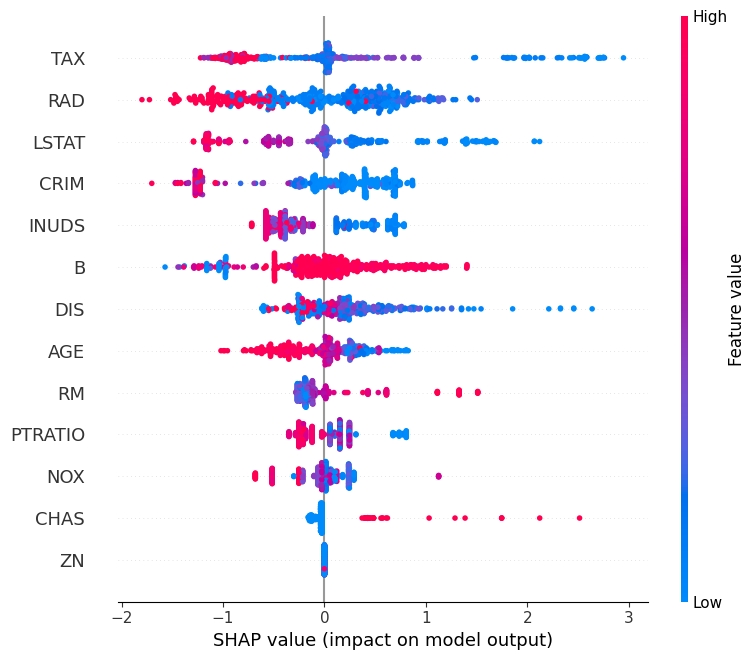

In [ ]:
shap.summary_plot(shap_values, X, plot_type="dot", show=False)

So we see that TAX is feature with the most impact on target and its low value means higher predictive price, also RAD (means close to highways) has also high effect on target.

## **4) Linear Regression Assumptions**

### **4.1) Linearity**

In [ ]:
residuals = y_test - y_pred_lr

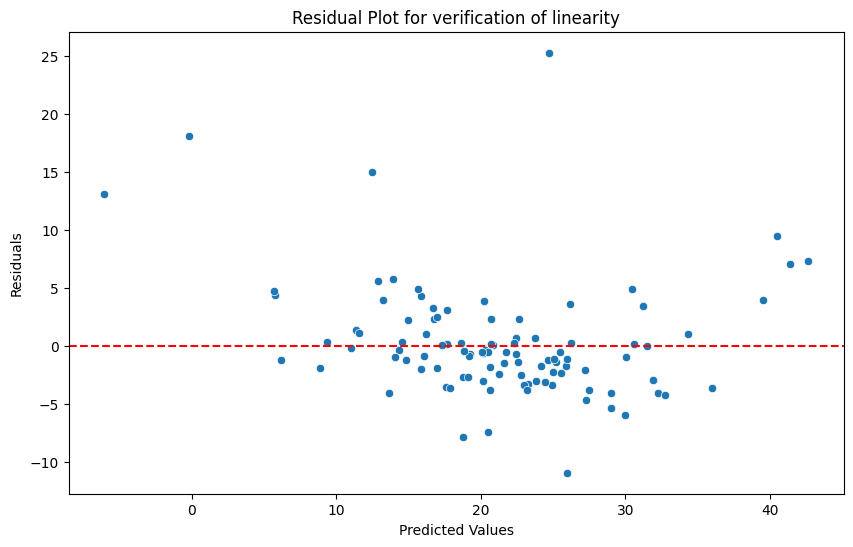

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_lr, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')

plt.title('Residual Plot for verification of linearity')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

There is a clear evidence that most of values are close to 0 so linearity should be fullfild. But there are some outlier values that could warn us that this model is not that optimal. Also we could see that there could be some sort of heteroscedascity because that outlier values happen to be more often on the edges of our plot.

### **4.2) Residuals normality**

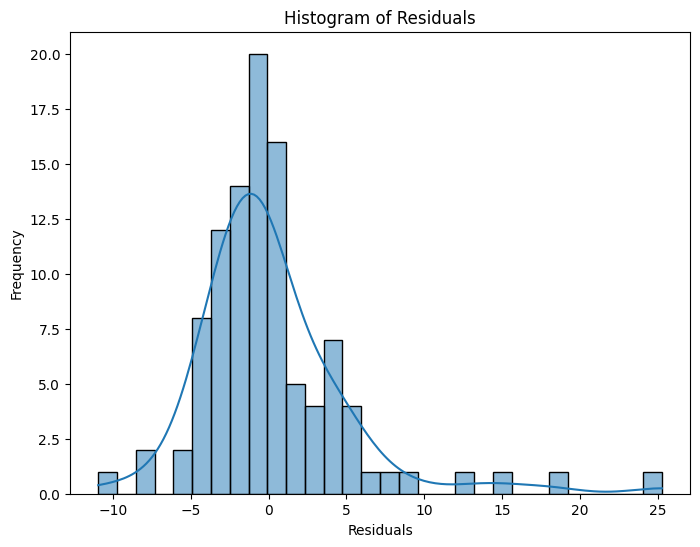

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30)

plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

As we discovered earlier most of them are around 0 but there happend to be outliers

In [ ]:
from scipy import stats
import statsmodels.api as sm

<Figure size 800x600 with 0 Axes>

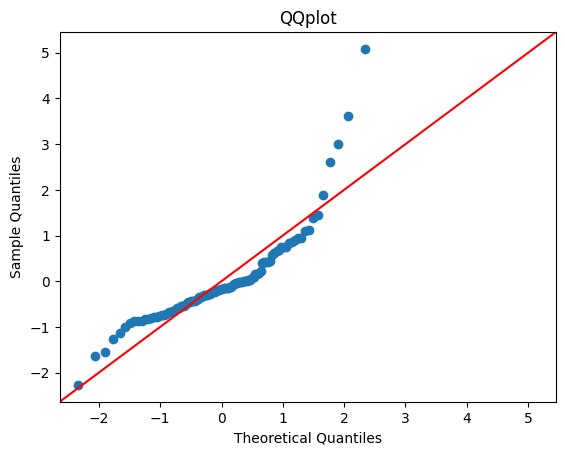

In [ ]:
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title('QQplot')
plt.show()

QQ plot also show us that in edging quantiles there are more outling values

## **5) Conclusions**

- After feature importance based on SHAP values for XGBoost model, we discover that socio-economic and location factors over physical attributes. TAX, RAD, and LSTAT are the dominant features. The plot clearly shows that high taxes, poor highway accessibility, and a higher percentage of lower-status population strongly decrease property value.

- Linear Regression Assumptions: The residual plot confirms heteroscedasticity and also reveals U-shaped pattern. This indicates non-linearity, meaning the linear model is failing to capture proper relationships in the data that is why XGBoost worked better than LR.